In [7]:
import torch
import torch.nn as nn

In [ ]:
import os

# Use relative path or set your dataset path here
# Option 1: Relative path (if dataset is in project)
# path = './data/casting_512x512'

# Option 2: Set your local path (for local development)
path = '/mnt/d/Datasets/CastingProductImageDataset/casting_512x512'

# TODO: Update the path above to your dataset location before training

classes = os.listdir(path)
num_classes = len(classes)

In [9]:
print('Number of classes:', classes)

Number of classes: ['def_front', 'ok_front']


## Data Loading and Preprocessing

In [10]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Define transforms for training (with augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Define transforms for validation (no augmentation)
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [11]:
# Create datasets
train_dataset = datasets.ImageFolder(
    root=path,
    transform=train_transforms
)

# Split into train and validation (80/20 split)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

# Apply validation transforms to validation set
val_dataset.dataset.transform = val_transforms

print(f'Training samples: {len(train_dataset)}')
print(f'Validation samples: {len(val_dataset)}')
print(f'Classes: {train_dataset.dataset.classes}')

Training samples: 1040
Validation samples: 260
Classes: ['def_front', 'ok_front']


In [12]:
# Create data loaders
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f'Training batches: {len(train_loader)}')
print(f'Validation batches: {len(val_loader)}')

Training batches: 33
Validation batches: 9


## Define ResNet Model

In [13]:
from torchvision import models

# Load pretrained ResNet50
model = models.resnet50(pretrained=True)

# Modify the final layer for binary classification
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, num_classes)

# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print(f'Using device: {device}')
print(f'Model output classes: {num_classes}')

/home/verma/miniconda3/envs/torch_env/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/verma/miniconda3/envs/torch_env/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Using device: cuda
Model output classes: 2


## Training Setup

In [14]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

# Training parameters
num_epochs = 20

In [15]:
# Early stopping parameters
patience = 5  # Number of epochs to wait for improvement
min_delta = 0.001  # Minimum change in validation loss to be considered as improvement

early_stopping_counter = 0
best_val_loss = float('inf')

print(f'Early stopping enabled with patience: {patience} epochs')

Early stopping enabled with patience: 5 epochs


## Training Loop

In [16]:
import time
from tqdm import tqdm

# Initialize lists to store metrics for each epoch
# These will be used later for plotting training progress
train_losses = []       # Training loss per epoch
val_losses = []         # Validation loss per epoch
train_accuracies = []   # Training accuracy per epoch
val_accuracies = []     # Validation accuracy per epoch
best_val_acc = 0.0      # Track the best validation accuracy achieved

# Main training loop - iterates through all epochs
for epoch in range(num_epochs):
    start_time = time.time()  # Record start time to measure epoch duration
    
    # ===== TRAINING PHASE =====
    model.train()  # Set model to training mode (enables dropout, batch norm training behavior)
    running_loss = 0.0  # Accumulate loss for this epoch
    correct = 0         # Count correct predictions
    total = 0           # Count total samples processed
    
    # Iterate through all training batches
    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} - Training'):
        # Move data to GPU/CPU device
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass: compute predictions and loss
        optimizer.zero_grad()        # Clear gradients from previous step
        outputs = model(images)      # Get model predictions
        loss = criterion(outputs, labels)  # Calculate loss between predictions and true labels
        
        # Backward pass: compute gradients and update weights
        loss.backward()    # Backpropagate the loss to compute gradients
        optimizer.step()   # Update model weights using computed gradients
        
        # Calculate statistics for monitoring
        running_loss += loss.item()  # Accumulate batch loss
        _, predicted = torch.max(outputs.data, 1)  # Get class with highest probability
        total += labels.size(0)      # Count samples in this batch
        correct += (predicted == labels).sum().item()  # Count correct predictions
    
    # Calculate average metrics for the training epoch
    train_loss = running_loss / len(train_loader)  # Average loss across all batches
    train_acc = 100 * correct / total              # Accuracy as percentage
    train_losses.append(train_loss)                # Store for plotting
    train_accuracies.append(train_acc)
    
    # ===== VALIDATION PHASE =====
    model.eval()  # Set model to evaluation mode (disables dropout, uses batch norm population stats)
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    
    # No gradient computation needed during validation (saves memory and computation)
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} - Validation'):
            # Move data to device
            images, labels = images.to(device), labels.to(device)
            
            # Forward pass only (no backward pass during validation)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Calculate validation statistics
            val_running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)  # Get predicted class
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    # Calculate average validation metrics
    val_loss = val_running_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    
    # Update learning rate according to scheduler (reduces LR every 7 epochs)
    scheduler.step()
    
    # Calculate and display epoch statistics
    epoch_time = time.time() - start_time
    
    print(f'\nEpoch [{epoch+1}/{num_epochs}] - Time: {epoch_time:.2f}s')
    print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
    
    # ===== MODEL CHECKPOINT =====
    # Save model weights if this is the best validation accuracy so far
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_defect_detection_resnet.pth')
        print(f'✓ Saved best model with validation accuracy: {val_acc:.2f}%')
    
    # ===== EARLY STOPPING CHECK =====
    # Stop training if validation loss hasn't improved for 'patience' epochs
    if val_loss < best_val_loss - min_delta:
        # Validation loss improved significantly
        best_val_loss = val_loss
        early_stopping_counter = 0  # Reset counter
        print(f'✓ Validation loss improved to {val_loss:.4f}')
    else:
        # No improvement in validation loss
        early_stopping_counter += 1
        print(f'⚠ No improvement in validation loss for {early_stopping_counter}/{patience} epochs')
        
        # If no improvement for 'patience' epochs, stop training
        if early_stopping_counter >= patience:
            print(f'\n🛑 Early stopping triggered after {epoch+1} epochs')
            print(f'Best validation loss: {best_val_loss:.4f}')
            print(f'Best validation accuracy: {best_val_acc:.2f}%')
            break  # Exit the training loop
    
    print('-' * 60)

Epoch 1/20 - Validation: 100%|████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:02<00:00,  4.27it/s]



Epoch [1/20] - Time: 16.39s
Train Loss: 0.4261, Train Acc: 84.62%
Val Loss: 4.4419, Val Acc: 63.08%
✓ Saved best model with validation accuracy: 63.08%
✓ Validation loss improved to 4.4419
------------------------------------------------------------


Epoch 2/20 - Validation: 100%|████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:01<00:00,  4.63it/s]



Epoch [2/20] - Time: 18.10s
Train Loss: 0.1209, Train Acc: 95.67%
Val Loss: 0.2191, Val Acc: 94.23%
✓ Saved best model with validation accuracy: 94.23%
✓ Validation loss improved to 0.2191
------------------------------------------------------------


Epoch 3/20 - Validation: 100%|████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:02<00:00,  4.30it/s]


...


Epoch [16/20] - Time: 14.73s
Train Loss: 0.0020, Train Acc: 100.00%
Val Loss: 0.0192, Val Acc: 99.23%
⚠ No improvement in validation loss for 3/5 epochs
------------------------------------------------------------


Epoch 17/20 - Validation: 100%|███████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:01<00:00,  4.73it/s]



Epoch [17/20] - Time: 17.80s
Train Loss: 0.0022, Train Acc: 100.00%
Val Loss: 0.0191, Val Acc: 99.23%
⚠ No improvement in validation loss for 4/5 epochs
------------------------------------------------------------


Epoch 18/20 - Validation: 100%|███████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:01<00:00,  4.53it/s]


Epoch [18/20] - Time: 14.72s
Train Loss: 0.0029, Train Acc: 99.90%
Val Loss: 0.0210, Val Acc: 99.23%
⚠ No improvement in validation loss for 5/5 epochs

🛑 Early stopping triggered after 18 epochs
Best validation loss: 0.0167
Best validation accuracy: 99.62%


## Visualize Training Results

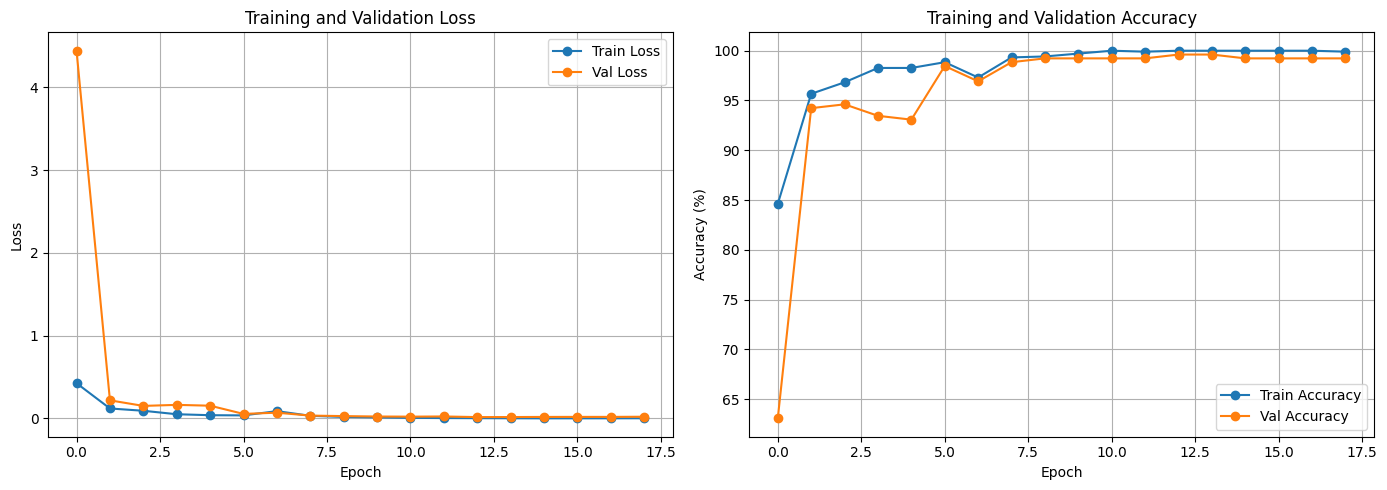


Best Validation Accuracy: 99.62%


In [17]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(train_losses, label='Train Loss', marker='o')
ax1.plot(val_losses, label='Val Loss', marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

# Accuracy plot
ax2.plot(train_accuracies, label='Train Accuracy', marker='o')
ax2.plot(val_accuracies, label='Val Accuracy', marker='o')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f'\nBest Validation Accuracy: {best_val_acc:.2f}%')

In [ ]:
# Save model with relative path (saves in current directory)
torch.save(model.state_dict(), 'final_defect_detection_resnet.pth')
print('Model saved successfully!')